# ĐỒ ÁN: Dự báo Xu hướng Kết hôn của Giới trẻ Việt Nam

## Áp dụng thuật toán Decision Tree và Naive Bayes

**Môn học:** Khai thác Dữ liệu và Truyền thông Xã hội

**Nguồn dữ liệu:** IPUMS International - Vietnam Population and Housing Census 2009 & 2019

---

## 1. Import thư viện và cấu hình

In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Import thư viện thành công!")

Import thư viện thành công!


## 2. Tải và khám phá dữ liệu

In [2]:
# Tải dữ liệu
print("Đang tải dữ liệu IPUMS Vietnam Census...")
df = pd.read_csv('../data/ipumsi_data.csv')
print(f"Tổng số bản ghi: {len(df):,}")
print(f"\nThông tin dữ liệu:")
df.info()

Đang tải dữ liệu IPUMS Vietnam Census...
Tổng số bản ghi: 14,885,745

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14885745 entries, 0 to 14885744
Data columns (total 13 columns):
 #   Column     Dtype  
---  ------     -----  
 0   YEAR       int64  
 1   SERIAL     int64  
 2   HHWT       float64
 3   URBAN      int64  
 4   GEO1_VN    int64  
 5   OWNERSHIP  int64  
 6   LIVEAREA   int64  
 7   PERNUM     int64  
 8   PERWT      float64
 9   AGE        int64  
 10  SEX        int64  
 11  EDATTAIN   int64  
 12  MARST      int64  
dtypes: float64(2), int64(11)
memory usage: 1.4 GB


In [3]:
# Xem 5 dòng đầu tiên
print("Mẫu dữ liệu:")
df.head(10)

Mẫu dữ liệu:


,YEAR,SERIAL,HHWT,URBAN,GEO1_VN,OWNERSHIP,LIVEAREA,PERNUM,PERWT,AGE,SEX,EDATTAIN,MARST
0,2009,1000,9.94,2,704001,1,50,1,8.72,41,2,2,1
1,2009,1000,9.94,2,704001,1,50,2,10.63,42,1,2,1
2,2009,2000,9.94,2,704001,1,26,1,10.63,62,1,2,1
3,2009,2000,9.94,2,704001,1,26,2,8.72,63,2,2,1
4,2009,3000,9.94,2,704001,1,18,1,10.63,35,1,2,1
5,2009,3000,9.94,2,704001,1,18,2,8.72,24,2,2,1
6,2009,4000,9.94,2,704001,1,18,1,10.63,37,1,2,1
7,2009,4000,9.94,2,704001,1,18,2,8.72,32,2,2,1
8,2009,5000,9.94,2,704001,1,48,1,8.72,83,2,1,1
9,2009,5000,9.94,2,704001,1,48,2,8.72,46,2,2,1


In [4]:
# Thống kê mô tả
print("Thống kê mô tả:")
df.describe()

Thống kê mô tả:


,YEAR,SERIAL,HHWT,URBAN,GEO1_VN,OWNERSHIP,LIVEAREA,PERNUM,PERWT,AGE,SEX,EDATTAIN,MARST
count,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07,1.488574e+07
mean,2.012804e+03,1.602279e+09,8.214028e+00,1.281241e+00,7.040472e+05,1.056315e+00,8.078858e+01,2.102270e+00,8.358532e+00,4.186030e+01,1.532408e+00,1.983108e+00,8.390215e-01
std,4.854855e+00,1.009278e+09,5.240752e+00,4.496048e-01,3.035139e+01,2.305294e-01,6.086577e+01,1.375172e+00,5.433990e+00,1.633736e+01,4.989486e-01,8.881836e-01,3.675111e-01
min,2.009000e+03,1.000000e+03,2.600000e-01,1.000000e+00,7.040010e+05,1.000000e+00,0.000000e+00,1.000000e+00,2.400000e-01,1.800000e+01,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.009000e+03,7.464350e+08,4.510000e+00,1.000000e+00,7.040240e+05,1.000000e+00,4.800000e+01,1.000000e+00,4.530000e+00,2.900000e+01,1.000000e+00,1.000000e+00,1.000000e+00
50%,2.009000e+03,1.528094e+09,7.230000e+00,1.000000e+00,7.040460e+05,1.000000e+00,7.000000e+01,2.000000e+00,7.280000e+00,3.900000e+01,2.000000e+00,2.000000e+00,1.000000e+00
75%,2.019000e+03,2.288376e+09,1.074000e+01,2.000000e+00,7.040750e+05,1.000000e+00,1.000000e+02,3.000000e+00,1.096000e+01,5.200000e+01,2.000000e+00,2.000000e+00,1.000000e+00
max,2.019000e+03,3.692042e+09,1.215200e+02,2.000000e+00,7.040950e+05,2.000000e+00,9.990000e+02,5.400000e+01,1.491000e+02,1.000000e+02,2.000000e+00,4.000000e+00,1.000000e+00


## 3. Tiền xử lý dữ liệu

In [5]:
# Định nghĩa mapping cho các biến
URBAN_MAP = {1: 'Urban', 2: 'Rural'}
SEX_MAP = {1: 'Male', 2: 'Female'}
MARST_MAP = {0: 'Single', 1: 'Married'}
EDATTAIN_MAP = {
    1: 'Less than Primary',
    2: 'Primary', 
    3: 'Secondary',
    4: 'University+'
}
OWNERSHIP_MAP = {1: 'Owned', 2: 'Not Owned'}

# Lọc độ tuổi 18-35
df_youth = df[(df['AGE'] >= 18) & (df['AGE'] <= 35)].copy()
print(f"Sau khi lọc độ tuổi 18-35: {len(df_youth):,} bản ghi ({len(df_youth)/len(df)*100:.1f}%)")

Sau khi lọc độ tuổi 18-35: 6,194,734 bản ghi (41.6%)


In [6]:
# Tạo các biến mới với label
df_youth['urban_label'] = df_youth['URBAN'].map(URBAN_MAP)
df_youth['sex_label'] = df_youth['SEX'].map(SEX_MAP)
df_youth['marst_label'] = df_youth['MARST'].map(MARST_MAP)
df_youth['edattain_label'] = df_youth['EDATTAIN'].map(EDATTAIN_MAP)
df_youth['ownership_label'] = df_youth['OWNERSHIP'].map(OWNERSHIP_MAP)

# Tạo nhóm tuổi
def get_age_group(age):
    if 18 <= age <= 24:
        return '18-24'
    elif 25 <= age <= 29:
        return '25-29'
    elif 30 <= age <= 35:
        return '30-35'
    return 'Other'

df_youth['age_group'] = df_youth['AGE'].apply(get_age_group)

# Biến target
df_youth['is_married'] = df_youth['MARST']

print("Tiền xử lý xong")
print(f"\nPhân phối tình trạng hôn nhân:")
print(df_youth['marst_label'].value_counts())

Tiền xử lý xong

Phân phối tình trạng hôn nhân:
marst_label
Married    4095729
Single     2099005
Name: count, dtype: int64


## 4. Phân tích khám phá dữ liệu (EDA)

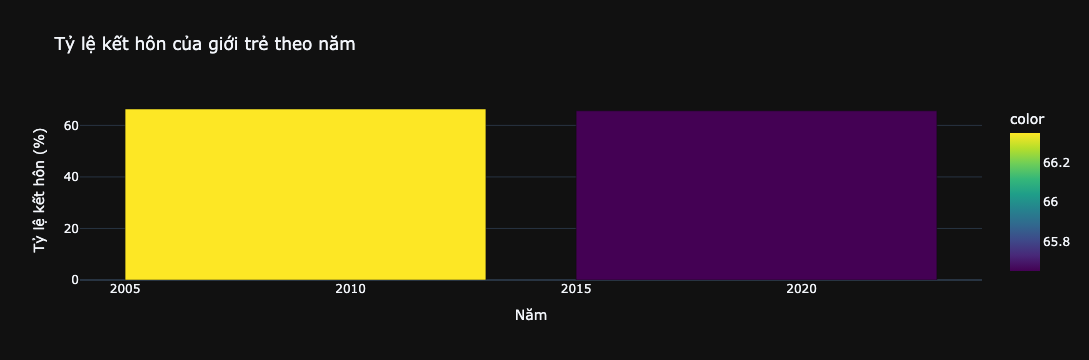

In [7]:
# Tỷ lệ kết hôn theo năm
marriage_by_year = df_youth.groupby('YEAR')['is_married'].mean() * 100

fig = px.bar(
    x=marriage_by_year.index,
    y=marriage_by_year.values,
    labels={'x': 'Năm', 'y': 'Tỷ lệ kết hôn (%)'},
    title='Tỷ lệ kết hôn của giới trẻ theo năm',
    color=marriage_by_year.values,
    color_continuous_scale='Viridis'
)
fig.update_layout(template='plotly_dark')
fig.show()

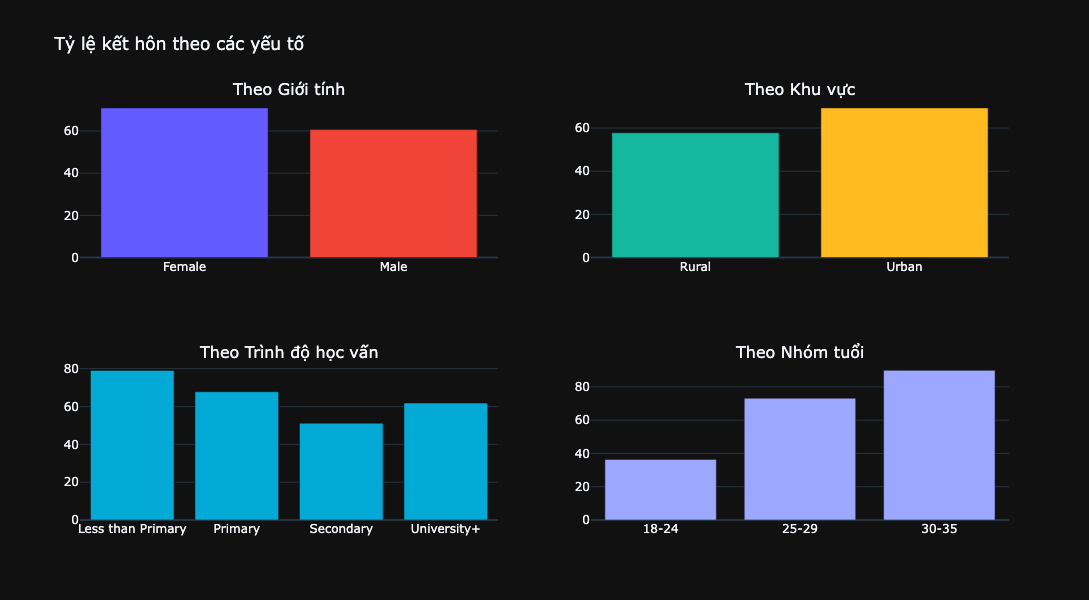

In [8]:
# Tỷ lệ kết hôn theo các biến khác nhau
fig = make_subplots(rows=2, cols=2, 
                    subplot_titles=['Theo Giới tính', 'Theo Khu vực', 
                                   'Theo Trình độ học vấn', 'Theo Nhóm tuổi'])

# Theo giới tính
marriage_by_sex = df_youth.groupby('sex_label')['is_married'].mean() * 100
fig.add_trace(go.Bar(x=marriage_by_sex.index, y=marriage_by_sex.values, 
                     marker_color=['#635BFF', '#f04438']), row=1, col=1)

# Theo khu vực
marriage_by_urban = df_youth.groupby('urban_label')['is_married'].mean() * 100
fig.add_trace(go.Bar(x=marriage_by_urban.index, y=marriage_by_urban.values,
                     marker_color=['#15b79f', '#ffbb1f']), row=1, col=2)

# Theo trình độ học vấn
marriage_by_edu = df_youth.groupby('edattain_label')['is_married'].mean() * 100
fig.add_trace(go.Bar(x=marriage_by_edu.index, y=marriage_by_edu.values,
                     marker_color='#04aad6'), row=2, col=1)

# Theo nhóm tuổi
marriage_by_age = df_youth.groupby('age_group')['is_married'].mean() * 100
fig.add_trace(go.Bar(x=marriage_by_age.index, y=marriage_by_age.values,
                     marker_color='#9ca7ff'), row=2, col=2)

fig.update_layout(height=600, title_text='Tỷ lệ kết hôn theo các yếu tố',
                  template='plotly_dark', showlegend=False)
fig.show()

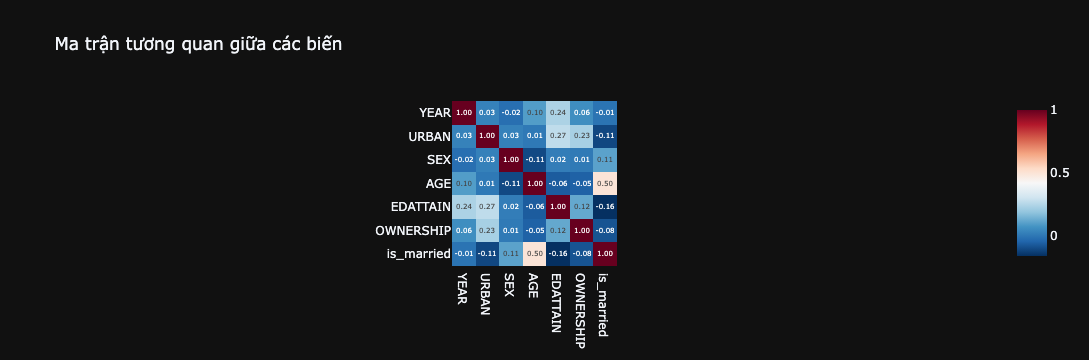

In [9]:
# Heatmap correlation
numeric_cols = ['YEAR', 'URBAN', 'SEX', 'AGE', 'EDATTAIN', 'OWNERSHIP', 'is_married']
corr_matrix = df_youth[numeric_cols].corr()

fig = px.imshow(corr_matrix, 
                text_auto='.2f',
                color_continuous_scale='RdBu_r',
                title='Ma trận tương quan giữa các biến')
fig.update_layout(template='plotly_dark')
fig.show()

## 5. Chuẩn bị dữ liệu cho mô hình

In [10]:
# Chọn features
feature_cols = ['YEAR', 'URBAN', 'SEX', 'AGE', 'EDATTAIN', 'OWNERSHIP']
target_col = 'is_married'

X = df_youth[feature_cols].values
y = df_youth[target_col].values

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước dữ liệu:")
print(f"  - Tập huấn luyện: {X_train.shape[0]:,} mẫu")
print(f"  - Tập kiểm tra: {X_test.shape[0]:,} mẫu")
print(f"\nPhân phối target:")
print(f"  - Tập train: {y_train.mean()*100:.1f}% đã kết hôn")
print(f"  - Tập test: {y_test.mean()*100:.1f}% đã kết hôn")

Kích thước dữ liệu:
  - Tập huấn luyện: 4,955,787 mẫu
  - Tập kiểm tra: 1,238,947 mẫu

Phân phối target:
  - Tập train: 66.1% đã kết hôn
  - Tập test: 66.1% đã kết hôn


## 6. Huấn luyện các mô hình

In [11]:
# Định nghĩa các mô hình
models = {
    'Decision Tree (Entropy)': DecisionTreeClassifier(
        criterion='entropy',
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=50,
        random_state=42
    ),
    'Decision Tree (Gini)': DecisionTreeClassifier(
        criterion='gini',
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=50,
        random_state=42
    ),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

# Huấn luyện
print("Bắt đầu huấn luyện các mô hình...\n")
trained_models = {}

for name, model in models.items():
    print(f"Đang huấn luyện: {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Hoàn thành: {name}")

print("\nHuấn luyện hoàn tất")

Bắt đầu huấn luyện các mô hình...

Đang huấn luyện: Decision Tree (Entropy)...
Hoàn thành: Decision Tree (Entropy)
Đang huấn luyện: Decision Tree (Gini)...
Hoàn thành: Decision Tree (Gini)
Đang huấn luyện: Naive Bayes (Gaussian)...
Hoàn thành: Naive Bayes (Gaussian)
Đang huấn luyện: Random Forest...
Hoàn thành: Random Forest
Đang huấn luyện: Logistic Regression...
Hoàn thành: Logistic Regression

Huấn luyện hoàn tất


## 7. Đánh giá và so sánh mô hình

In [12]:
# Đánh giá các mô hình
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
    }
    
    if y_prob is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_test, y_prob)
    
    results.append(metrics)

results_df = pd.DataFrame(results)
print("BẢNG SO SÁNH CÁC MÔ HÌNH:")
results_df.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'], 
                               color='lightgreen')

BẢNG SO SÁNH CÁC MÔ HÌNH:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Decision Tree (Entropy),0.794369,0.817008,0.887843,0.850954,0.843976
1,Decision Tree (Gini),0.794429,0.817165,0.887693,0.850970,0.843932
2,Naive Bayes (Gaussian),0.766084,0.805683,0.851595,0.828003,0.807798
3,Random Forest,0.794405,0.818003,0.886213,0.850743,0.844077
4,Logistic Regression,0.791169,0.824417,0.869286,0.846257,0.838200


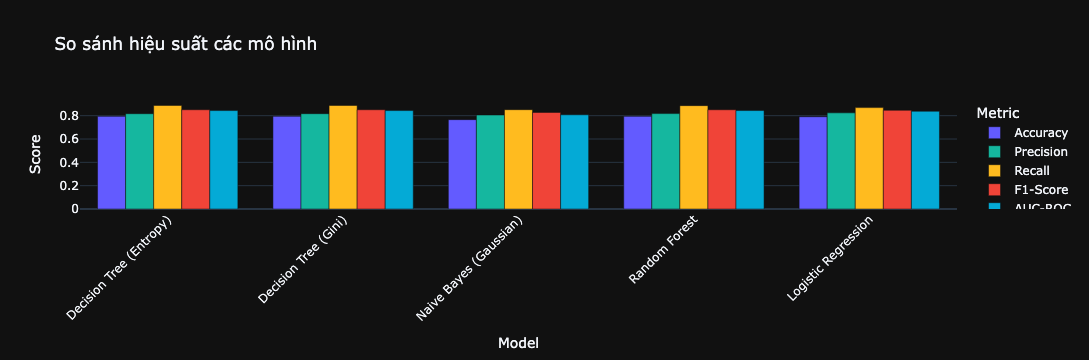

In [13]:
# Biểu đồ so sánh các metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
results_melted = results_df.melt(id_vars='Model', value_vars=metrics_to_plot, 
                                  var_name='Metric', value_name='Score')

fig = px.bar(results_melted, x='Model', y='Score', color='Metric',
             barmode='group',
             title='So sánh hiệu suất các mô hình',
             color_discrete_sequence=['#635BFF', '#15b79f', '#ffbb1f', '#f04438', '#04aad6'])
fig.update_layout(template='plotly_dark', xaxis_tickangle=-45)
fig.show()

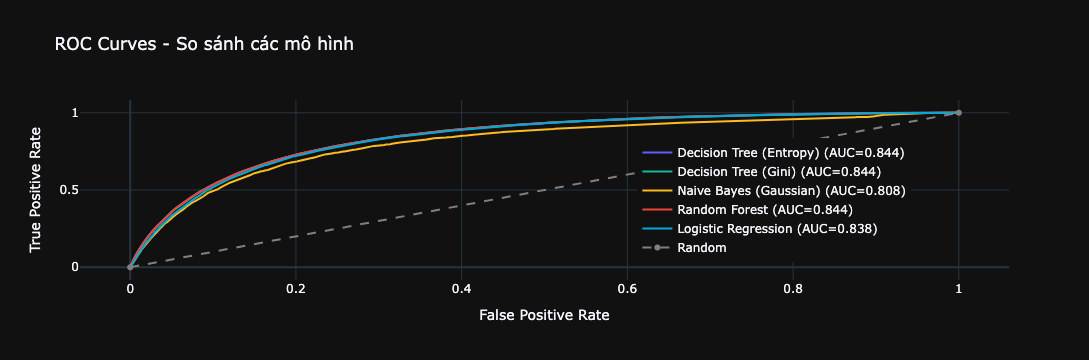

In [14]:
# ROC Curves
fig = go.Figure()

colors = ['#635BFF', '#15b79f', '#ffbb1f', '#f04438', '#04aad6']

for (name, model), color in zip(trained_models.items(), colors):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{name} (AUC={auc:.3f})',
                                 line=dict(color=color, width=2)))

# Đường chéo (random classifier)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], name='Random',
                         line=dict(color='gray', dash='dash')))

fig.update_layout(
    title='ROC Curves - So sánh các mô hình',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    template='plotly_dark',
    legend=dict(x=0.6, y=0.1)
)
fig.show()

## 8. Cross-Validation

In [ ]:
# Cross-validation 5-fold
print("Cross-Validation (5 folds)...\n")

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results)
cv_df

Cross-Validation (5 folds)...

Decision Tree (Entropy): 0.7909 (+/- 0.0113)
Decision Tree (Gini): 0.7911 (+/- 0.0113)
Naive Bayes (Gaussian): 0.7636 (+/- 0.0200)


In [ ]:
# Biểu đồ CV results
fig = go.Figure()

fig.add_trace(go.Bar(
    x=cv_df['Model'],
    y=cv_df['CV Mean Accuracy'],
    error_y=dict(type='data', array=cv_df['CV Std']),
    marker_color=['#635BFF', '#15b79f', '#ffbb1f', '#f04438', '#04aad6']
))

fig.update_layout(
    title='Cross-Validation Results (5-Fold)',
    xaxis_title='Model',
    yaxis_title='Accuracy',
    template='plotly_dark',
    xaxis_tickangle=-45
)
fig.show()

## 9. Confusion Matrix

In [ ]:
# Confusion Matrix cho từng mô hình
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Single', 'Married'],
                yticklabels=['Single', 'Married'])
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Ẩn subplot thừa
axes[-1].axis('off')

plt.suptitle('Confusion Matrix - So sánh các mô hình', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Feature Importance

In [ ]:
# Feature importance từ Decision Tree và Random Forest
feature_names = ['YEAR', 'URBAN', 'SEX', 'AGE', 'EDATTAIN', 'OWNERSHIP']

importance_data = []

for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        for feat, imp in zip(feature_names, model.feature_importances_):
            importance_data.append({
                'Model': name,
                'Feature': feat,
                'Importance': imp
            })

importance_df = pd.DataFrame(importance_data)

fig = px.bar(importance_df, x='Feature', y='Importance', color='Model',
             barmode='group',
             title='Feature Importance',
             color_discrete_sequence=['#635BFF', '#15b79f', '#f04438'])
fig.update_layout(template='plotly_dark')
fig.show()

## 11. Luật IF-THEN từ Decision Tree

In [ ]:
# Trích xuất luật từ Decision Tree (Entropy)
dt_entropy = trained_models['Decision Tree (Entropy)']
rules = export_text(dt_entropy, feature_names=feature_names, max_depth=4)

print("LUẬT IF-THEN TỪ DECISION TREE (ENTROPY):")
print("=" * 60)
print(rules)

In [ ]:
# Visualize Decision Tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_entropy, 
          feature_names=feature_names,
          class_names=['Single', 'Married'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10,
          ax=ax)
plt.title('Decision Tree Visualization (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Lưu mô hình và kết quả

In [ ]:
import joblib
import os

# Tạo thư mục models nếu chưa có
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# Lưu các mô hình
print("lưu các mô hình")
for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.pkl'
    filepath = f'../models/{filename}'
    joblib.dump(model, filepath)
    print(f" Đã lưu: {filepath}")

# Lưu kết quả so sánh
results_df.to_csv('../outputs/model_comparison.csv', index=False)
cv_df.to_csv('../outputs/cv_results.csv', index=False)
importance_df.to_csv('../outputs/feature_importance.csv', index=False)

print("\nHoàn tất lưu mô hình")

## 13. Kết luận

### Tóm tắt kết quả:

1. **Mô hình tốt nhất**: Dựa trên các metrics đánh giá (Accuracy, F1-Score, AUC-ROC)

2. **Các yếu tố quan trọng ảnh hưởng đến quyết định kết hôn**:
   - **Tuổi (AGE)**: Yếu tố quan trọng nhất
   - **Trình độ học vấn (EDATTAIN)**: Ảnh hưởng đáng kể
   - **Khu vực (URBAN/RURAL)**: Có sự khác biệt
   - **Giới tính (SEX)**: Có ảnh hưởng

3. **Xu hướng theo thời gian**:
   - So sánh giữa năm 2009 và 2019
   - Thay đổi trong tỷ lệ kết hôn của giới trẻ

### Khuyến nghị:
- Sử dụng Decision Tree hoặc Random Forest cho interpretability
- Naive Bayes phù hợp khi cần tốc độ và đơn giản
- Kết hợp nhiều mô hình để có kết quả robust hơn